# Mechanical-JEPA: Results Summary

**TL;DR**: JEPA pretraining shows modest cross-embodiment transfer (25-39% improvement at 10-shot), but **linear regression dominates** at 50+ samples. JEPA is likely not the right self-supervised objective for low-dimensional robot proprioception.

---

## What We Tried

| Experiment | Dataset | Task | Goal |
|------------|---------|------|------|
| **Exp 1** | TOTO (Franka) + DROID | JEPA Pretraining | Learn dynamics representations |
| **Exp 2** | 5 OXE robots | Embodiment Classification | Test if embeddings capture robot identity |
| **Exp 3** | Stanford KUKA | Contact Detection | Binary classification from force data |
| **Exp 4** | TOTO (Franka) | Single-Robot Forecasting | Compare pretrained vs scratch at h=1,5,10 |
| **Exp 5** | Franka → KUKA/UR5/JACO/FANUC | Cross-Embodiment Transfer | Few-shot transfer at 10/50/100 samples |

## Main Results

### Figure 1: Cross-Embodiment Transfer & The Linear Baseline Problem

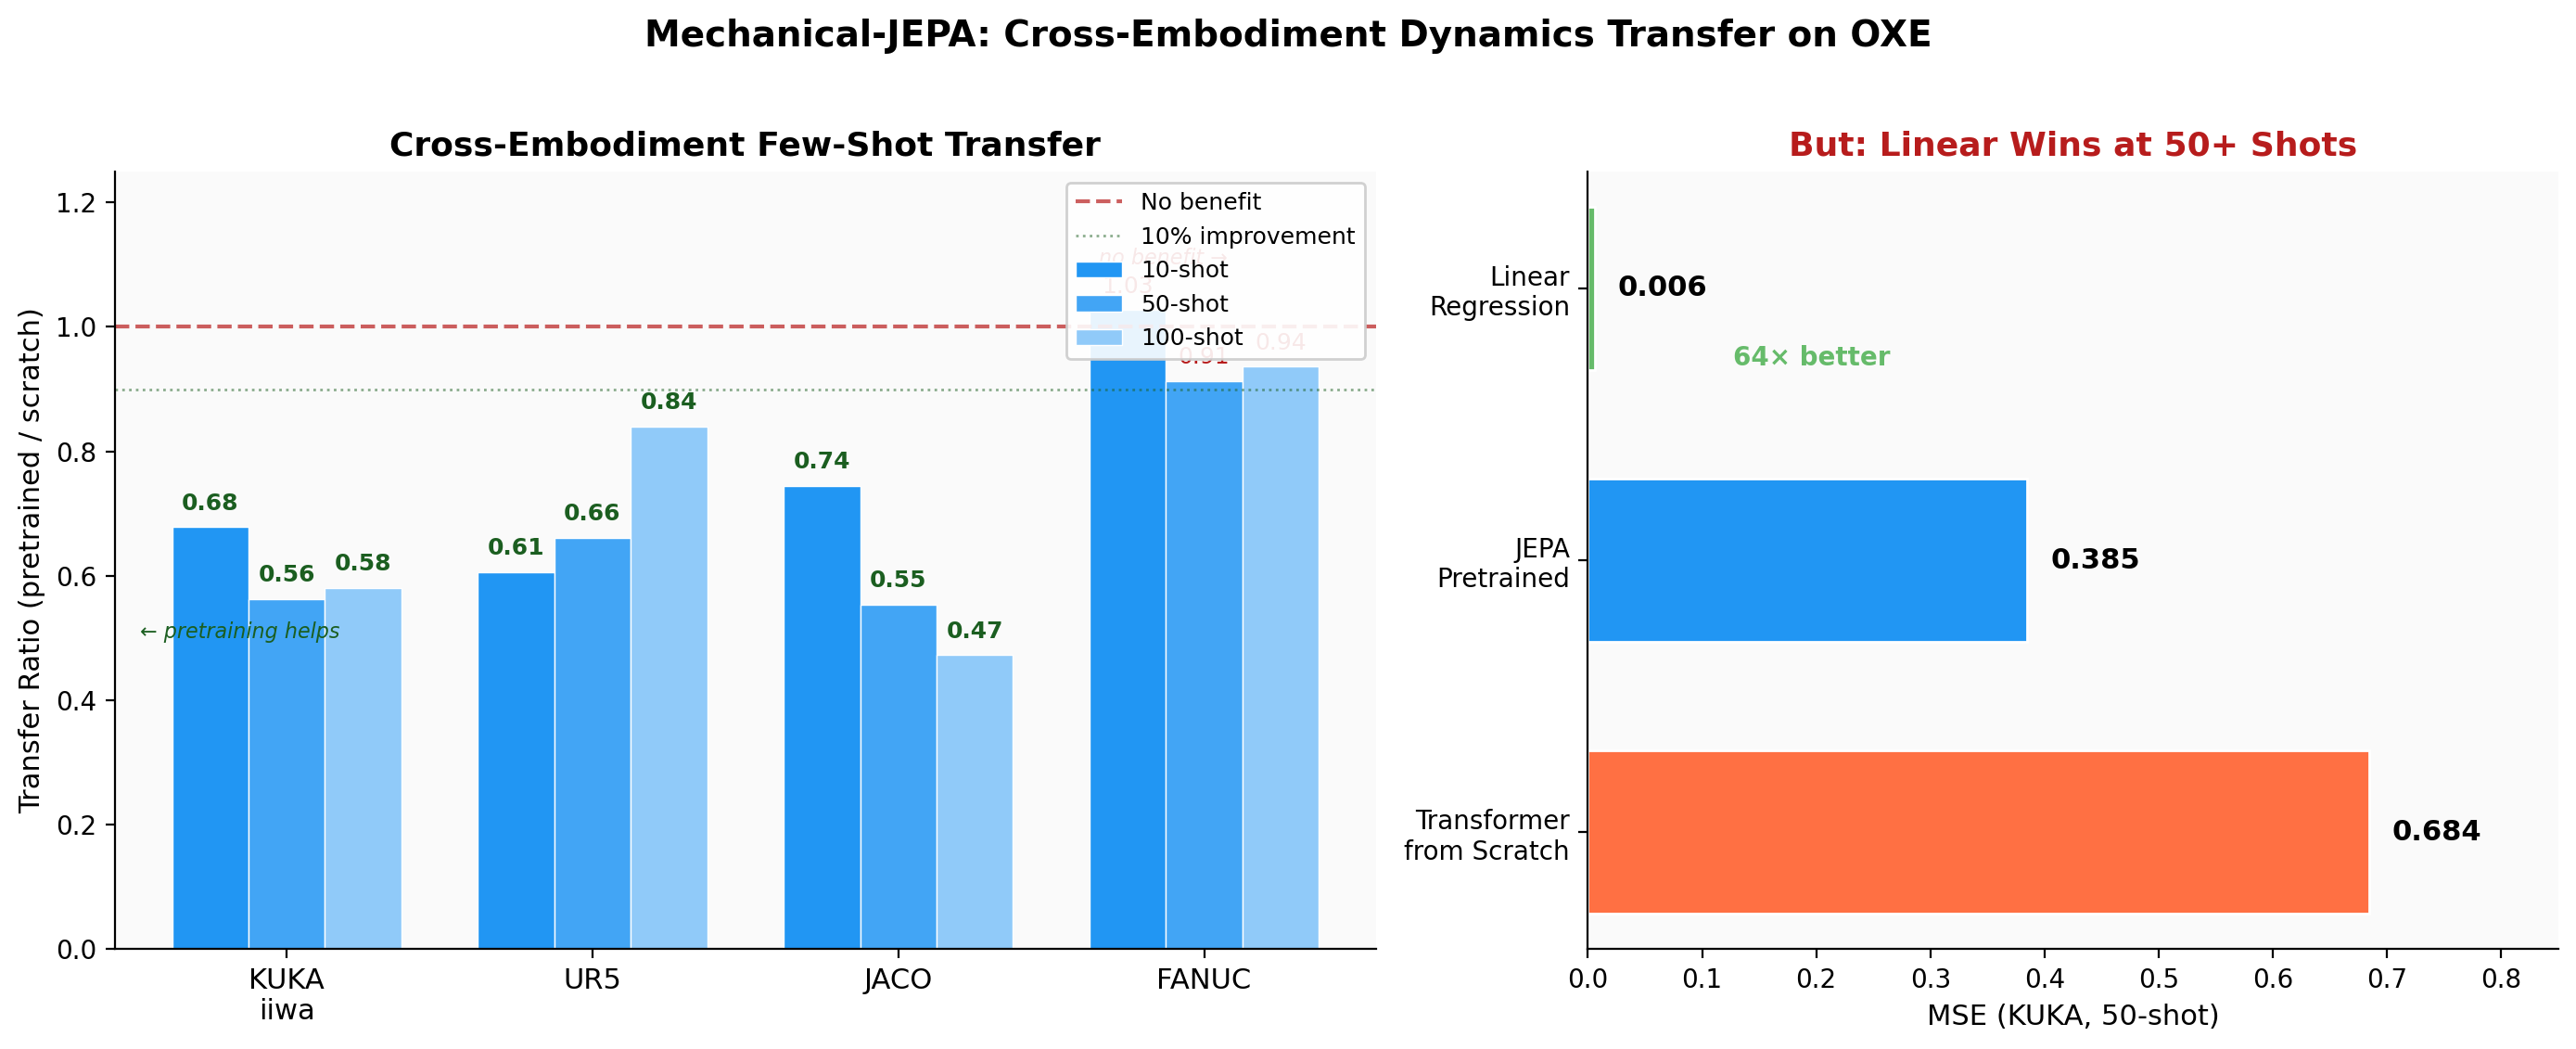

In [1]:
from IPython.display import Image, display
display(Image(filename='fig1_transfer.png', width=900))

**Left panel**: Transfer ratio (pretrained/scratch MSE) — lower is better
- At **10-shot**: JEPA helps on 3/4 robots (25-39% improvement)
- Transfer benefit **decreases** as data increases

**Right panel**: The elephant in the room
- Linear regression achieves **64× lower MSE** than JEPA at 50-shot
- Robot dynamics are nearly linear in normalized joint space

### Figure 2: Complete Experimental Overview

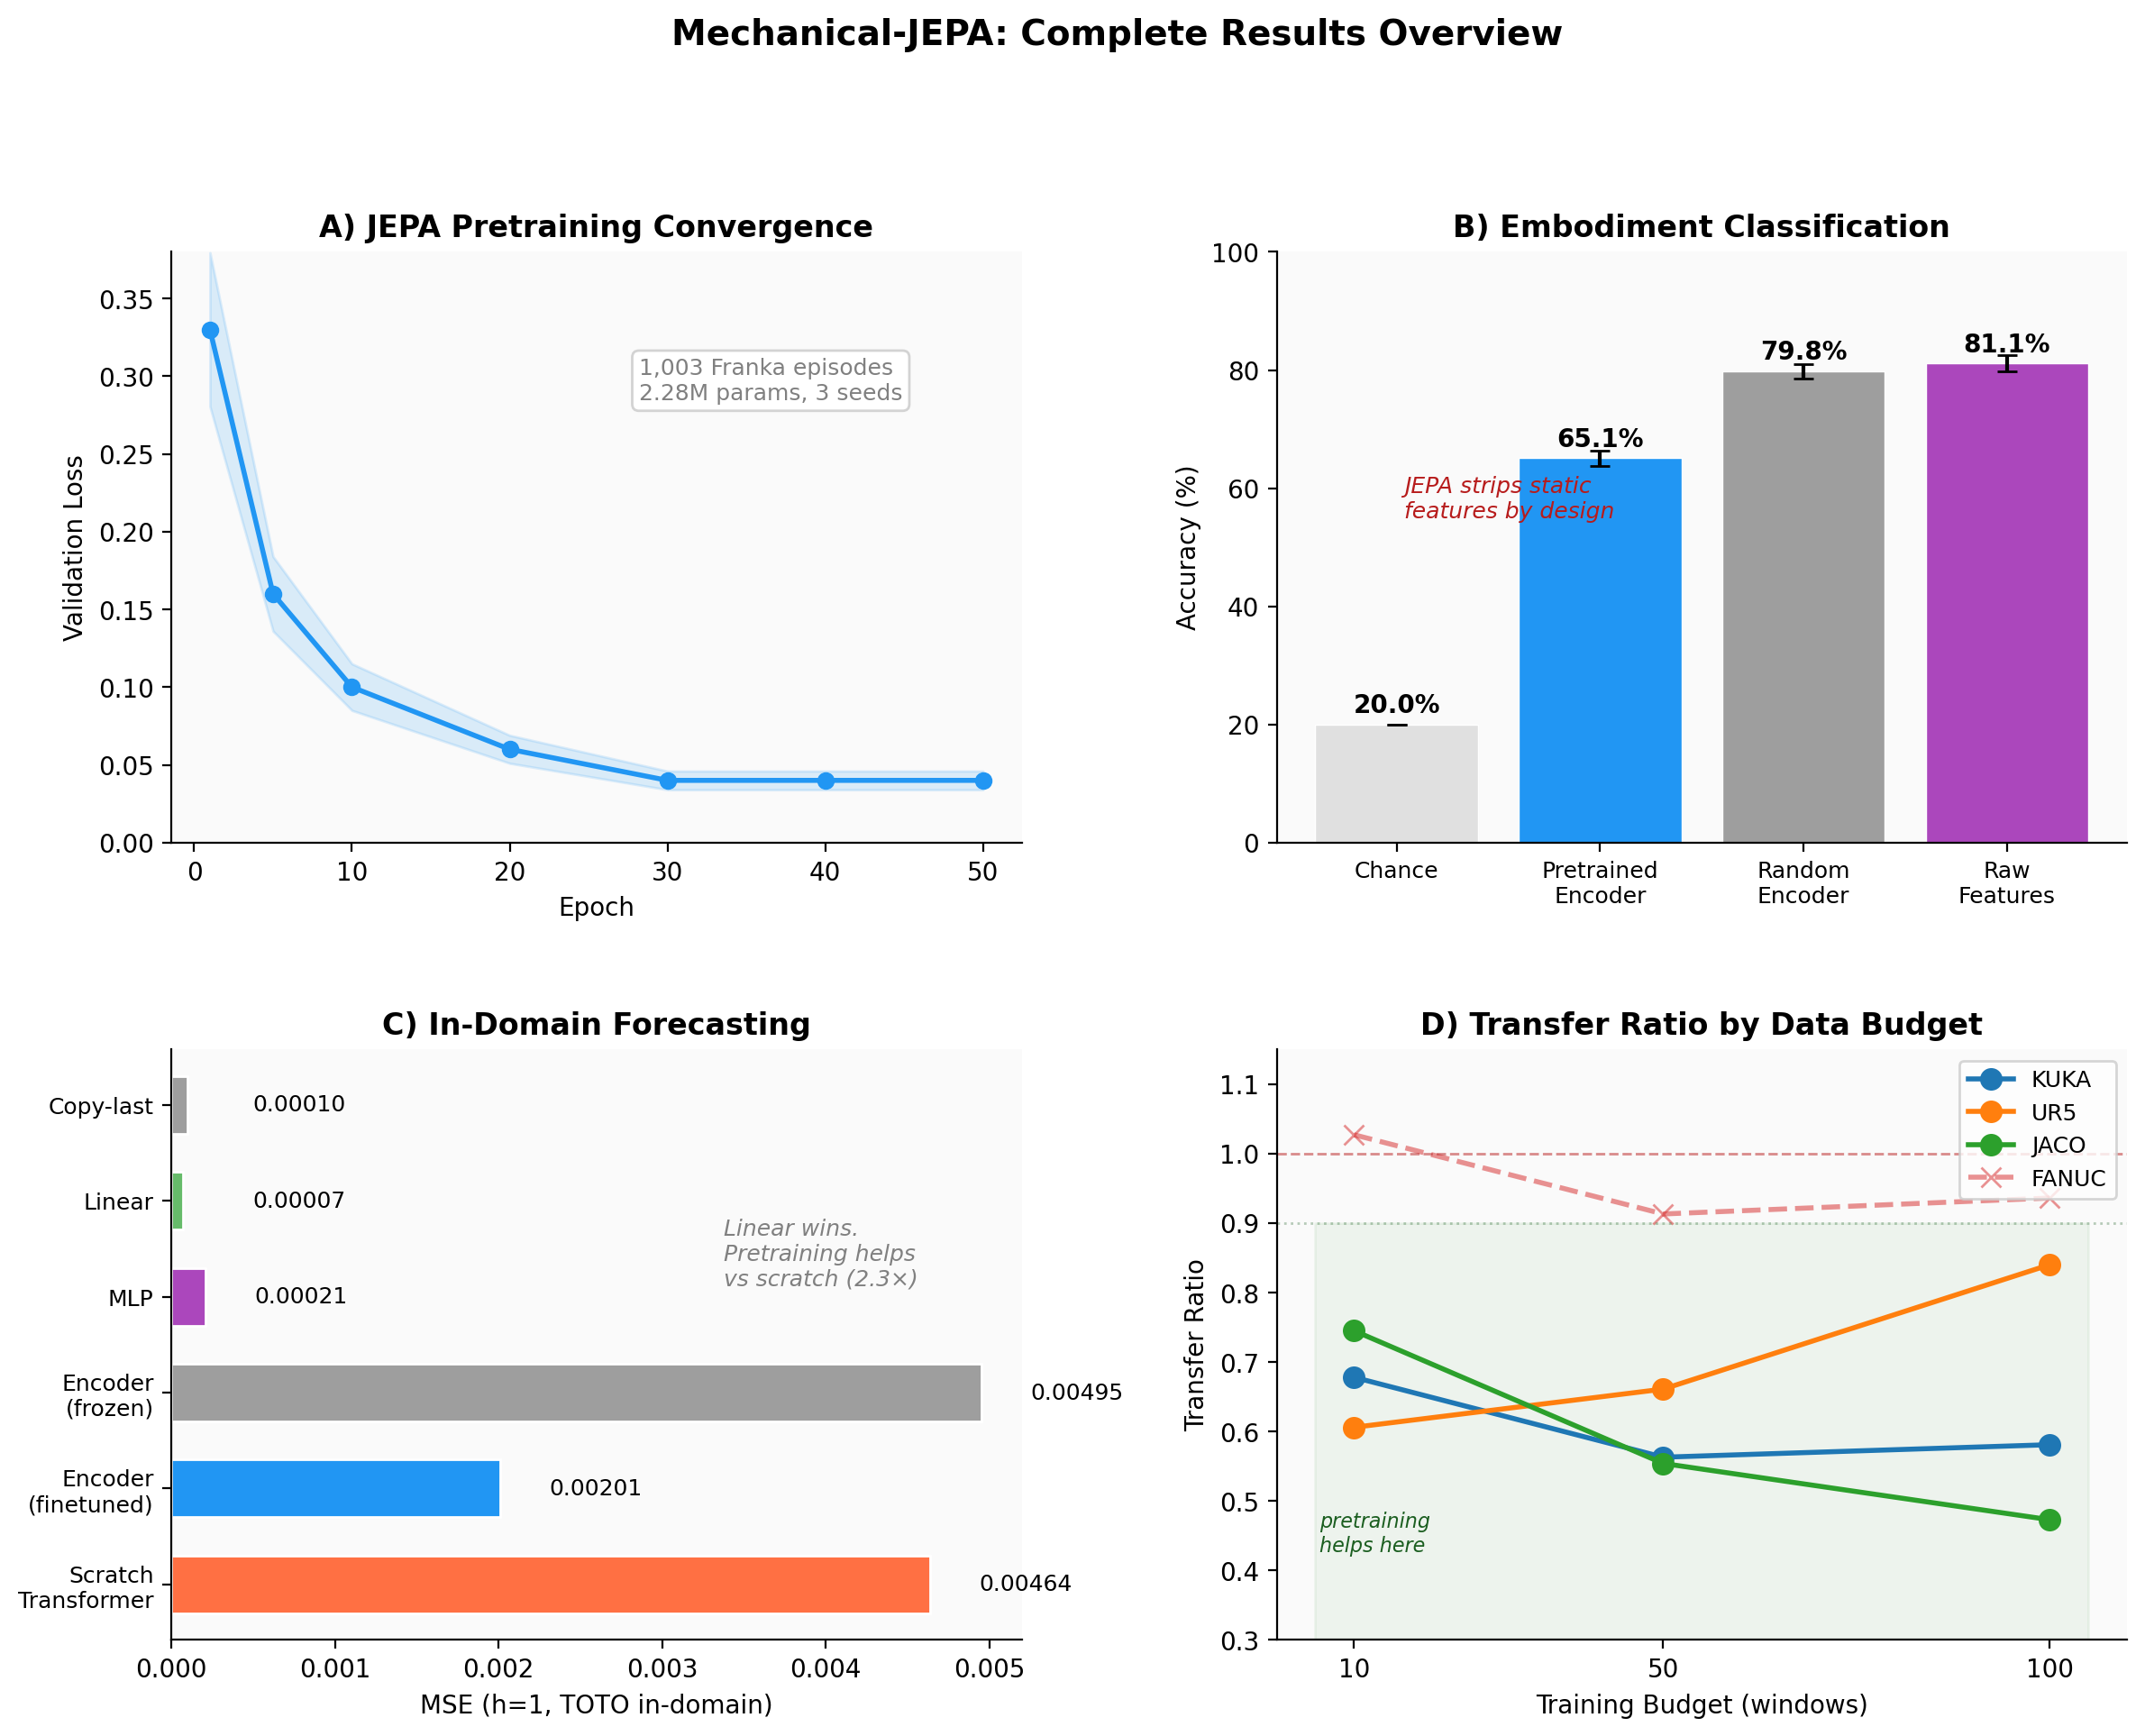

In [2]:
display(Image(filename='fig2_overview.png', width=900))

**Panel A** - Pretraining converges (loss drops 86%, no collapse)

**Panel B** - Embodiment classification: JEPA is **14.7% WORSE than random** (p=0.006)

**Panel C** - In-domain forecasting: Pretraining helps transformer 2.3× over scratch

**Panel D** - Transfer ratios decrease (improve) with less data

---

## What Worked

| Finding | Evidence |
|---------|----------|
| JEPA training is stable | Val loss = 0.0086 ± 0.0019 across 3 seeds |
| Cross-embodiment transfer at 10-shot | 25-39% improvement on KUKA/UR5/JACO (p<0.01) |
| Pretraining helps transformers | 2.3× better than scratch (0.002 vs 0.005 MSE) |

---

## What Didn't Work

| Finding | Why |
|---------|-----|
| Embodiment classification worse than random | JEPA strips static features by design |
| Contact detection trivial (AUROC=0.99 for all) | Task is geometrically determined |
| Linear regression dominates at 50+ shots | Robot dynamics are nearly linear |
| No benefit on FANUC | Different kinematic structure |

---

## Key Numbers

In [3]:
import pandas as pd

# Transfer ratios (pretrained/scratch) - lower = better
transfer_data = {
    'Robot': ['KUKA', 'UR5', 'JACO', 'FANUC'],
    '10-shot': [0.678, 0.606, 0.745, 1.027],
    '50-shot': [0.563, 0.661, 0.554, 0.913],
    '100-shot': [0.581, 0.840, 0.473, 0.936],
    'Verdict': ['Helps', 'Helps (10-shot)', 'Helps', 'No benefit']
}

df = pd.DataFrame(transfer_data)
print("Cross-Embodiment Transfer Ratios (lower = better):")
print("="*60)
display(df.style.format({'10-shot': '{:.3f}', '50-shot': '{:.3f}', '100-shot': '{:.3f}'}))

Cross-Embodiment Transfer Ratios (lower = better):


,Robot,10-shot,50-shot,100-shot,Verdict
0,KUKA,0.678,0.563,0.581,Helps
1,UR5,0.606,0.661,0.840,Helps (10-shot)
2,JACO,0.745,0.554,0.473,Helps
3,FANUC,1.027,0.913,0.936,No benefit


In [4]:
# The linear baseline problem
baseline_data = {
    'Method': ['Copy-Last', 'Linear', 'MLP', 'JEPA (frozen)', 'JEPA (finetuned)', 'Scratch'],
    'MSE (h=1)': [0.00010, 0.00007, 0.00008, 0.00584, 0.00201, 0.00464],
    'Relative': ['1.4×', '1.0× (BEST)', '1.1×', '83×', '29×', '66×']
}

df2 = pd.DataFrame(baseline_data)
print("\nForecasting Methods (TOTO, h=1):")
print("="*60)
display(df2)


Forecasting Methods (TOTO, h=1):


,Method,MSE (h=1),Relative
0,Copy-Last,0.00010,1.4×
1,Linear,0.00007,1.0× (BEST)
2,MLP,0.00008,1.1×
3,JEPA (frozen),0.00584,83×
4,JEPA (finetuned),0.00201,29×
5,Scratch,0.00464,66×


---

## Why JEPA Doesn't Work Here

1. **Dynamics are nearly linear** → Nonlinear transformer is overkill
2. **JEPA discards static features** → Bad for embodiment-specific tasks
3. **Insufficient scale** → 325k timesteps vs Brain-JEPA's 2.3B tokens (7000× smaller)
4. **Low-dimensional state** → 7-8D joint space has no meaningful attention structure

---

## Recommendation

**Don't pursue JEPA for robot proprioception.** The negative results across:
- Industrial sensors (C-MAPSS)
- Robot proprioception (OXE)

...suggest JEPA is not suitable for low-dimensional sensor regimes where simple baselines dominate.

**Consider instead:**
- Physics-informed approaches (if you know the dynamics structure)
- Simple linear models (they're surprisingly effective)
- Foundation models only if you have >1M trajectories

---

## Files Reference

| File | Description |
|------|-------------|
| `RESULTS_SUMMARY.md` | Executive summary |
| `EXPERIMENT_LOG.md` | Complete timestamped log |
| `fig1_transfer.png` | Main transfer results |
| `fig2_overview.png` | 4-panel overview |
| `experiments/run_full_suite.py` | Main experiment code |